# From NeqSim mechanical design to interactive 3D equipment

**Calculate → size → qualify → generate → inspect → export.**

This tutorial generates a horizontal separator and an eight-stage compressor illustration
directly from executed NeqSim calculations. Change the feed rate, rerun the design, and the vessel
dimensions and 3D geometry update together. The same vessel-building functions can represent a
scrubber once its reviewed dimensions and orientation are supplied.

[Open in Colab](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/mechanical_design_to_3d_models.ipynb)
· [Example book](../examples_of_NeqSim_in_Colab.ipynb)

You will learn to extract dimensioned mechanical results, create parametric meshes with **Trimesh**,
inspect cutaways with **Plotly**, retain static views, compare flow cases, and exchange **STL / GLB /
JSON** files. The compressor cutaway illustrates the style of a detailed equipment STL; its blade
and support details are explicitly illustrative. All fluid and operating data here are synthetic.

**Scope:** preliminary process-driven geometry for teaching, concept screening and design review.
The meshes are not vendor manufacturing drawings or completed pressure-vessel/rotordynamic designs.

## 1. What comes from which calculation?

| Layer | Owns | Output used here |
|---|---|---|
| NeqSim process model | SRK phase equilibrium, stream rates, compression | Actual volumes, mass balances, power and temperature |
| NeqSim mechanical design | Preliminary vessel and rotor dimensions | Diameter, tangent length, wall thickness, stages, shaft and impeller diameters |
| Reviewed handoff | Units, identities and qualification checks | Small JSON contract with tags, provenance and assumptions |
| Python geometry | Shapes and placement | Named meshes, cutaways and layout |
| Trimesh / Plotly | Mesh inspection and display | STL/GLB, interactive views and stored figures |

Dimensions are in **metres** throughout the geometry layer; pressures are **bara** and displayed
temperatures are **°C**. Compressor diameter getters use **mm**, whereas the separator wall-thickness
getter returns **m** in the tested source. Explicit conversion is essential.

NeqSim does not determine the exact head profile, nozzle coordinates, flange bolt pattern, support
loads, impeller blades or maintenance access in this example. Those choices are separately labelled.
The vessel has illustrative 2:1 ellipsoidal external heads. Nozzle tubes are placement envelopes:
they are not boolean-cut penetrations through the pressure shell.

## 2. Clean Colab setup and source provenance

Run all cells in order in a fresh runtime. Python packages are pinned to the tested versions.
The `neqsim` wheel provides the Python bridge; Java calculations use a JAR built from current
`equinor/neqsim` master. The first source build can take several minutes and requires Java 17+
and internet access. `NEQSIM_SOURCE_REF` may be a reviewed commit to reproduce an earlier run.
Local validators may supply `NEQSIM_SOURCE_ROOT` and `NEQSIM_SOURCE_JAR` for that exact source build.
The resolved commit, JAR digest and loaded class location are always checked and displayed.

In [1]:
import importlib.metadata
import os
from pathlib import Path
import subprocess
import sys

package_versions = {
    "neqsim": "3.20.0",
    "trimesh": "5.1.0",
    "plotly": "7.0.0",
    "numpy": "2.5.3",
    "pandas": "3.0.5",
    "matplotlib": "3.11.2",
    "scipy": "1.18.1",
    "networkx": "3.6.1",
    "shapely": "2.1.2",
}
requirements = []
for package, required in package_versions.items():
    try:
        installed = importlib.metadata.version(package)
    except importlib.metadata.PackageNotFoundError:
        installed = None
    if installed != required:
        requirements.append(f"{package}=={required}")
if requirements:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "--quiet", *requirements],
        check=True,
    )
print("Python packages:", package_versions)

Python packages: {'neqsim': '3.20.0', 'trimesh': '5.1.0', 'plotly': '7.0.0', 'numpy': '2.5.3', 'pandas': '3.0.5', 'matplotlib': '3.11.2', 'scipy': '1.18.1', 'networkx': '3.6.1', 'shapely': '2.1.2'}


In [2]:
import hashlib
import json
import platform
from urllib.parse import unquote, urlparse
import jpype


def run_command(command, cwd=None):
    result = subprocess.run(
        command,
        cwd=cwd,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        timeout=2400,
    )
    if result.returncode:
        raise RuntimeError(result.stdout[-8000:])
    return result.stdout.strip()


NEQSIM_SOURCE_REF = os.environ.get("NEQSIM_SOURCE_REF", "master")
supplied_root = os.environ.get("NEQSIM_SOURCE_ROOT")
supplied_jar = os.environ.get("NEQSIM_SOURCE_JAR")
if bool(supplied_root) != bool(supplied_jar):
    raise ValueError("Supply both source root and source JAR, or neither.")
if supplied_root:
    source_root = Path(supplied_root).resolve()
    source_jar = Path(supplied_jar).resolve()
else:
    source_root = Path("neqsim-java-3d-source").resolve()
    if not source_root.exists():
        run_command(["git", "init", str(source_root)])
        run_command(
            ["git", "remote", "add", "origin", "https://github.com/equinor/neqsim.git"],
            cwd=source_root,
        )
    run_command(
        ["git", "fetch", "--depth", "1", "origin", NEQSIM_SOURCE_REF],
        cwd=source_root,
    )
    run_command(["git", "checkout", "--detach", "FETCH_HEAD"], cwd=source_root)
    run_command(
        [
            "bash",
            "mvnw",
            "-q",
            "-Dmaven.test.skip=true",
            "-Dmaven.javadoc.skip=true",
            "package",
        ],
        cwd=source_root,
    )
    candidates = [
        path
        for path in (source_root / "target").glob("neqsim-*.jar")
        if "sources" not in path.name and "javadoc" not in path.name
    ]
    source_jar = max(candidates, key=lambda path: path.stat().st_size)

source_commit = run_command(["git", "rev-parse", "HEAD"], cwd=source_root)
jar_sha256 = hashlib.sha256(source_jar.read_bytes()).hexdigest()
os.environ["NEQSIM_JVM_AUTOSTART"] = "0"
if jpype.isJVMStarted():
    raise RuntimeError("Restart the kernel so the source-built JAR is loaded first.")
jpype.addClassPath(str(source_jar))
jpype.startJVM()
JClass = jpype.JClass
provenance_class = JClass("neqsim.process.mechanicaldesign.SystemMechanicalDesignResult")
class_url = str(provenance_class.class_.getProtectionDomain().getCodeSource().getLocation())
assert Path(unquote(urlparse(class_url).path)).resolve() == source_jar
provenance = {
    "source_repository": "https://github.com/equinor/neqsim",
    "source_ref": NEQSIM_SOURCE_REF,
    "source_commit": source_commit,
    "jar_sha256": jar_sha256,
    "loaded_class_url": class_url,
    "python": platform.python_version(),
    "java": str(JClass("java.lang.System").getProperty("java.version")),
    "packages": package_versions,
}
print(json.dumps(provenance, indent=2))

{
  "source_repository": "https://github.com/equinor/neqsim",
  "source_ref": "master",
  "source_commit": "7cdaa4d7259ee7b8d3d8c0db5d927270a1bef107",
  "jar_sha256": "137378d705ff0b7f80fd12ae4981981bff5c94215db9eaf263f9e5666e542da0",
  "loaded_class_url": "file:/workspace/scratch/314126d77740/neqsim-source/target/neqsim-3.20.0.jar",
  "python": "3.12.14",
  "java": "17.0.20",
  "packages": {
    "neqsim": "3.20.0",
    "trimesh": "5.1.0",
    "plotly": "7.0.0",
    "numpy": "2.5.3",
    "pandas": "3.0.5",
    "matplotlib": "3.11.2",
    "scipy": "1.18.1",
    "networkx": "3.6.1",
    "shapely": "2.1.2"
  }
}


In [3]:
import math
import shutil

from IPython.display import FileLink, display
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource, to_rgba
from matplotlib.patches import Rectangle
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import trimesh

SystemSrkEos = JClass("neqsim.thermo.system.SystemSrkEos")
Stream = JClass("neqsim.process.equipment.stream.Stream")
Separator = JClass("neqsim.process.equipment.separator.Separator")
Compressor = JClass("neqsim.process.equipment.compressor.Compressor")
ProcessSystem = JClass("neqsim.process.processmodel.ProcessSystem")

output_dir = Path("mechanical_3d_outputs")
output_dir.mkdir(exist_ok=True)
colors = {"shell": "#3c8692", "rotor": "#dfad50", "support": "#36485c", "pipe": "#b5c9cf"}
plt.rcParams.update({"font.size": 10, "figure.dpi": 110, "axes.titleweight": "bold"})

## 3. Run a composable separator–compressor process

The feed contains 80 mol% methane, 5% ethane, 5% propane and 10% n-decane at 20 bara and
40 °C. The deliberately rich mixture gives substantial gas and liquid outlets. SRK with the
classic mixing rule is used for this hydrocarbon example; no water phase is modelled.

The compressor raises the separated gas to 80 bara at 78% polytropic efficiency and 18,000 rpm.
Its mechanical stage count refers to **impellers within one uncooled compressor**, not separate
intercooled process units. This matters when interpreting its discharge temperature.

In [4]:
composition = {"methane": 0.80, "ethane": 0.05, "propane": 0.05, "n-decane": 0.10}
assert math.isclose(sum(composition.values()), 1.0)


def build_process(feed_kg_h, pressure_bara=20.0, speed_rpm=18000.0):
    fluid = SystemSrkEos(313.15, pressure_bara)
    for component, fraction in composition.items():
        fluid.addComponent(component, fraction)
    fluid.setMixingRule("classic")
    feed = Stream("feed", fluid)
    feed.setFlowRate(float(feed_kg_h), "kg/hr")
    vessel = Separator("V-101", feed)
    vessel.setOrientation("horizontal")
    compressor = Compressor("K-101", vessel.getGasOutStream())
    compressor.setOutletPressure(80.0)
    compressor.setUsePolytropicCalc(True)
    compressor.setPolytropicEfficiency(0.78)
    compressor.setSpeed(float(speed_rpm))
    process = ProcessSystem()
    for equipment in [feed, vessel, compressor]:
        process.add(equipment)
    process.run()
    return process, feed, vessel, compressor


process, feed, vessel, compressor = build_process(100000.0)
gas = vessel.getGasOutStream()
liquid = vessel.getLiquidOutStream()
streams = {
    "Feed": feed,
    "Separated gas": gas,
    "Liquid": liquid,
    "Compressed gas": compressor.getOutletStream(),
}
stream_table = pd.DataFrame(
    [
        {
            "Stream": name,
            "Mass [kg/h]": stream.getFlowRate("kg/hr"),
            "Actual volume [m³/h]": stream.getFlowRate("m3/hr"),
            "Pressure [bara]": stream.getPressure("bara"),
            "Temperature [°C]": stream.getTemperature("C"),
        }
        for name, stream in streams.items()
    ]
).set_index("Stream")
display(stream_table.round(3))
mass_error = abs(
    feed.getFlowRate("kg/hr") - gas.getFlowRate("kg/hr") - liquid.getFlowRate("kg/hr")
) / feed.getFlowRate("kg/hr")
assert mass_error < 1e-8
assert (
    abs(compressor.getOutletStream().getFlowRate("kg/hr") / gas.getFlowRate("kg/hr") - 1.0)
    < 1e-8
)
print(f"Separator relative mass error: {mass_error:.3e}")
print(f"Compressor shaft power: {compressor.getPower('kW'):.1f} kW")

Separator relative mass error: 2.310e-13
Compressor shaft power: 4326.0 kW


,Mass [kg/h],Actual volume [m³/h],Pressure [bara],Temperature [°C]
Stream,,,,
Feed,100000.000,3647.606,20.0,40.000
Separated gas,52015.774,3580.355,20.0,40.000
Liquid,47984.226,67.252,20.0,40.000
Compressed gas,52015.774,1308.149,80.0,172.983


The displayed discharge temperature is high. This synthetic uncooled case is suitable for
demonstrating the calculation-to-geometry handoff, but it has **not** passed a project temperature
limit or machinery selection review. Intercooling or a revised pressure split would be a process
design decision before procurement.

## 4. Qualify mechanical results before making a model

### 4.1 Vessel dimensions and repeatability

We specify 25 bara maximum operating design-basis pressure, 80 °C and a 2 mm corrosion allowance.
These are declared teaching inputs, not a complete governing-case envelope. NeqSim's current
separator path evaluates wall thickness before applying the newly calculated diameter
([issue #3677](https://github.com/equinor/neqsim/issues/3677)). Therefore we explicitly calculate,
apply and repeat until diameter, length and wall thickness stabilize. The iterations are retained.

In [5]:
def size_vessel(equipment):
    design = equipment.getMechanicalDesign()
    design.setMaxOperationPressure(25.0, "bara")
    design.setMaxOperationTemperature(80.0, "C")
    design.setCorrosionAllowance(2.0)  # This setter uses mm.
    history = []
    previous = None
    for iteration in range(1, 7):
        design.calcDesign()
        current = np.array(
            [
                design.getInnerDiameter(),
                design.getTantanLength(),
                design.getWallThickness(),
            ],
            dtype=float,
        )
        history.append([iteration, *current])
        design.setDesign()
        if previous is not None and np.allclose(current, previous, rtol=1e-9, atol=1e-12):
            break
        previous = current
    else:
        raise RuntimeError("Mechanical dimensions did not stabilize.")
    assert np.all(np.isfinite(current)) and np.all(current > 0)
    return design, pd.DataFrame(history, columns=["Pass", "ID [m]", "T/T [m]", "Wall [m]"])


vessel_design, design_history = size_vessel(vessel)
display(design_history.round(6))

,Pass,ID [m],T/T [m],Wall [m]
0,1,1.440917,7.204586,0.004952
1,2,1.440917,7.204586,0.006253
2,3,1.440917,7.204586,0.006253


### 4.2 Outlet nozzles: an independent velocity check

The current outlet-nozzle methods contain an extra division by 3600
([issue #3675](https://github.com/equinor/neqsim/issues/3675)). We retain their raw output, compare it
with actual stream flow, then explicitly set reviewed teaching diameters back onto the mechanical
design. This prevents an attractive mesh from hiding an undersized connection.

$$D_{\min}=\sqrt{\frac{4Q}{\pi v_{\max}}}.$$

Here $Q$ is actual volumetric flow in m³/s, $v_{\max}$ is the selected velocity in m/s and
$D_{\min}$ is the internal diameter in m. We use 20 m/s for gas and 1.5 m/s for liquid as illustrative
screens, followed by 50 mm and 25 mm rounding increments. These are **not pipe schedules** or a
substitute for erosion, noise, momentum, pressure-loss or vendor checks.

In [6]:
def reviewed_nozzles(equipment, design):
    raw_gas = float(design.calcGasOutletNozzleID())
    raw_liquid = float(design.calcOilOutletNozzleID())
    records = []
    for name, stream, raw, velocity_limit, increment in [
        ("Gas", equipment.getGasOutStream(), raw_gas, 20.0, 0.05),
        ("Liquid", equipment.getLiquidOutStream(), raw_liquid, 1.5, 0.025),
    ]:
        volume_m3_s = float(stream.getFlowRate("m3/hr")) / 3600.0
        minimum_id = math.sqrt(4.0 * volume_m3_s / (math.pi * velocity_limit))
        chosen_id = max(0.05, math.ceil(minimum_id / increment) * increment)
        velocity = 4.0 * volume_m3_s / (math.pi * chosen_id**2)
        assert velocity <= velocity_limit * (1.0 + 1e-12)
        records.append(
            {
                "Outlet": name,
                "Raw NeqSim ID [m]": raw,
                "Selected ID [m]": chosen_id,
                "Raw velocity [m/s]": 4.0 * volume_m3_s / (math.pi * raw**2),
                "Selected velocity [m/s]": velocity,
                "Limit [m/s]": velocity_limit,
            }
        )
    design.setGasOutletNozzleID(records[0]["Selected ID [m]"])
    design.setOilOutletNozzleID(records[1]["Selected ID [m]"])
    inlet_id = float(design.calcInletNozzleID())
    return inlet_id, pd.DataFrame(records).set_index("Outlet")


inlet_id, nozzle_table = reviewed_nozzles(vessel, vessel_design)
display(nozzle_table.round(4))

,Raw NeqSim ID [m],Selected ID [m],Raw velocity [m/s],Selected velocity [m/s],Limit [m/s]
Outlet,,,,,
Gas,0.05,0.30,506.5166,14.0699,20.0
Liquid,0.05,0.15,9.5142,1.0571,1.5


### 4.3 Compressor rotor dimensions

NeqSim calculates stage count, impeller and shaft diameters, bearing span and a preliminary casing.
We check the physical identity

$$U=\frac{\pi DN}{60},$$

where $U$ is impeller tip speed in m/s, $D$ is diameter in m and $N$ is shaft speed in rpm.
At 6,000 rpm this example triggers an inconsistent flow-coefficient adjustment in current source
([issue #3676](https://github.com/equinor/neqsim/issues/3676)); the 18,000-rpm case below passes this
identity. Passing this check does not validate critical speeds, stresses, surge or blade performance.

In [7]:
compressor_design = compressor.getMechanicalDesign()
compressor_design.calcDesign()
casing = compressor_design.getCasingDesignCalculator()
rotor = {
    "tag": "K-101",
    "stages": int(compressor_design.getNumberOfStages()),
    "impeller_diameter_m": float(compressor_design.getImpellerDiameter()) / 1000.0,
    "shaft_diameter_m": float(compressor_design.getShaftDiameter()) / 1000.0,
    "bearing_span_m": float(compressor_design.getBearingSpan()) / 1000.0,
    "casing_inner_diameter_m": float(casing.getCasingInnerDiameterMm()) / 1000.0,
    "casing_length_m": float(casing.getCasingLengthMm()) / 1000.0,
    "casing_wall_m": float(casing.getSelectedWallThicknessMm()) / 1000.0,
    "speed_rpm": float(compressor.getSpeed()),
    "tip_speed_m_s": float(compressor_design.getTipSpeed()),
    "driver_power_kW": float(compressor_design.getDriverPower()),
}
tip_from_geometry = math.pi * rotor["impeller_diameter_m"] * rotor["speed_rpm"] / 60.0
assert math.isclose(tip_from_geometry, rotor["tip_speed_m_s"], rel_tol=1e-8)
assert rotor["shaft_diameter_m"] < rotor["impeller_diameter_m"]
assert rotor["impeller_diameter_m"] < rotor["casing_inner_diameter_m"]
assert 1 <= rotor["stages"] <= 20
display(pd.DataFrame({"Calculated value": rotor}).drop(index="tag"))
print(f"Tip speed from D and N: {tip_from_geometry:.3f} m/s — consistent")

Tip speed from D and N: 241.627 m/s — consistent


,Calculated value
stages,8
impeller_diameter_m,0.256375
shaft_diameter_m,0.092403
bearing_span_m,1.897173
casing_inner_diameter_m,0.333287
casing_length_m,2.466324
casing_wall_m,0.016
speed_rpm,18000.0
tip_speed_m_s,241.627447
driver_power_kW,4758.643496


## 5. A small, explicit design-to-geometry contract

We use verified getters and explicit unit suffixes. Native mechanical JSON currently includes
some unpopulated/default fields ([issue #3678](https://github.com/equinor/neqsim/issues/3678)), so it
is not blindly used as a geometry specification. The raw API and source code remain available for
comparison. Unknown values must not be converted into fabricated design detail.

| Geometry field | Source | Status |
|---|---|---|
| Vessel ID, T/T length, shell wall | Iterated NeqSim mechanical design | Calculated, preliminary |
| Vessel outlet IDs | Actual NeqSim flows + explicit velocity screen | Notebook calculation applied to NeqSim |
| Impeller count, diameters, span, casing dimensions | Compressor mechanical getters | Calculated, preliminary |
| Head shape, nozzle coordinates, support sizes | Named Python assumptions | Illustrative |
| Blade count/shape and casing split for viewing | Named Python assumptions | Illustrative, not aerodynamic design |

In [8]:
vessel_spec = {
    "tag": "V-101",
    "orientation": "horizontal",
    "inner_diameter_m": float(vessel_design.getInnerDiameter()),
    "tangent_length_m": float(vessel_design.getTantanLength()),
    "wall_m": float(vessel_design.getWallThickness()),
    "inlet_id_m": inlet_id,
    "gas_outlet_id_m": float(vessel_design.getGasOutletNozzleID()),
    "liquid_outlet_id_m": float(vessel_design.getOilOutletNozzleID()),
    "normal_liquid_level_m": float(vessel_design.getNLL()),
}
assumptions = {
    "heads": "2:1 ellipsoidal external envelope; head thickness not calculated",
    "supports": "two geometric blocks with base plates; no structural analysis",
    "nozzles": "illustrative coordinates, projections and 8 mm tube wall; no shell holes",
    "rotor_blades": "10 straight illustrative vanes per stage; no aerodynamic claim",
    "casing_split": "display cut at horizontal midplane; no split-line joint design",
    "mesh_units": "m; explicitly supplied again when reading STL",
    "status": "educational preliminary geometry, review required",
}
handoff = {
    "schema_version": "1.0.0",
    "provenance": provenance,
    "operating_case": {
        "feed_kg_h": 100000.0,
        "pressure_bara": 20.0,
        "temperature_C": 40.0,
        "composition_mole_fraction": composition,
    },
    "vessel": vessel_spec,
    "compressor": rotor,
    "assumptions": assumptions,
}
print(json.dumps({"vessel": vessel_spec, "assumptions": assumptions}, indent=2))

{
  "vessel": {
    "tag": "V-101",
    "orientation": "horizontal",
    "inner_diameter_m": 1.440917294605802,
    "tangent_length_m": 7.20458647302901,
    "wall_m": 0.006253002640512992,
    "inlet_id_m": 0.30000000000000004,
    "gas_outlet_id_m": 0.30000000000000004,
    "liquid_outlet_id_m": 0.15000000000000002,
    "normal_liquid_level_m": 0.720458647302901
  },
  "assumptions": {
    "heads": "2:1 ellipsoidal external envelope; head thickness not calculated",
    "supports": "two geometric blocks with base plates; no structural analysis",
    "nozzles": "illustrative coordinates, projections and 8 mm tube wall; no shell holes",
    "rotor_blades": "10 straight illustrative vanes per stage; no aerodynamic claim",
    "casing_split": "display cut at horizontal midplane; no split-line joint design",
    "mesh_units": "m; explicitly supplied again when reading STL",
    "status": "educational preliminary geometry, review required"
  }
}


## 6. Generate geometry with Trimesh

The helpers accept a specification dictionary, rather than reading global NeqSim objects. This
separates calculation ownership from visualization and lets the same contract feed another CAD
tool later. The process objects remain available for further simulations.

The vessel envelope is a surface of revolution around its x axis. Components keep their equipment
and part names. The cutaway is a **display-only** open surface. It is intentionally different from
the closed envelope used for mesh-volume validation and STL round-trip tests.

Calculated vessel: ID 1.441 m × T/T 7.205 m; wall 6.25 mm


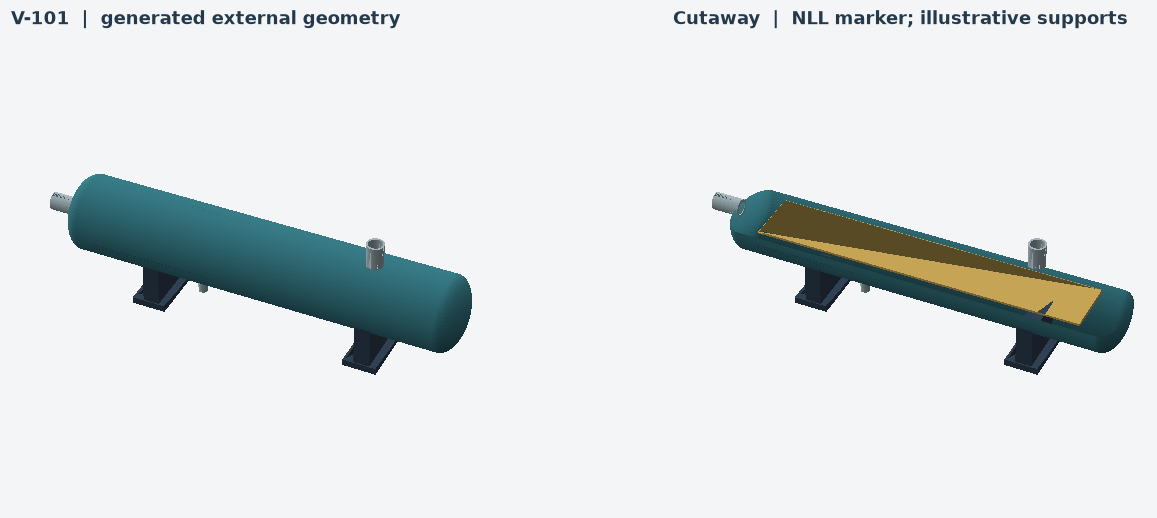

In [9]:
def add_part(scene, name, mesh, color):
    mesh.visual.face_colors = (np.array(to_rgba(color)) * 255).astype(np.uint8)
    mesh.units = "m"
    scene.add_geometry(mesh, node_name=name, geom_name=name)


def cylinder_x(radius, length, center=(0.0, 0.0, 0.0), sections=48):
    mesh = trimesh.creation.cylinder(radius=radius, height=length, sections=sections)
    mesh.apply_transform(trimesh.transformations.rotation_matrix(math.pi / 2, [0, 1, 0]))
    mesh.apply_translation(center)
    return mesh


def tube_x(inner_radius, outer_radius, length, center=(0.0, 0.0, 0.0)):
    mesh = trimesh.creation.annulus(
        r_min=inner_radius, r_max=outer_radius, height=length, sections=48
    )
    mesh.apply_transform(trimesh.transformations.rotation_matrix(math.pi / 2, [0, 1, 0]))
    mesh.apply_translation(center)
    return mesh


def box_at(extents, center):
    mesh = trimesh.creation.box(extents=extents)
    mesh.apply_translation(center)
    return mesh


def vessel_envelope(radius, length, sections=64, head_steps=18):
    # The 2:1 head depth is radius / 2. Revolve expects [radius, axial coordinate].
    angle = np.linspace(0.0, math.pi / 2, head_steps)
    left = np.column_stack([radius * np.sin(angle), -length / 2 - radius / 2 * np.cos(angle)])
    right = np.column_stack([radius * np.cos(angle), length / 2 + radius / 2 * np.sin(angle)])
    profile = np.vstack([left, right])
    profile[0, 0] = 0.0
    profile[-1, 0] = 0.0
    mesh = trimesh.creation.revolve(profile, sections=sections)
    mesh.apply_transform(trimesh.transformations.rotation_matrix(math.pi / 2, [0, 1, 0]))
    mesh.fix_normals()
    mesh.units = "m"
    return mesh


def vessel_scene(spec, cutaway=False):
    scene = trimesh.Scene()
    radius = spec["inner_diameter_m"] / 2 + spec["wall_m"]
    length = spec["tangent_length_m"]
    elevation = radius + 0.65
    envelope = vessel_envelope(radius, length)
    if cutaway:
        envelope = envelope.slice_plane([0, 0, 0], [0, 0, -1], cap=False)
    envelope.apply_translation([0, 0, elevation])
    add_part(scene, "V-101/shell-envelope", envelope, colors["shell"])
    for index, x in enumerate([-0.30 * length, 0.30 * length]):
        add_part(
            scene,
            f"V-101/support-{index + 1}",
            box_at([0.30, 1.35 * radius, 0.80], [x, 0, 0.45]),
            colors["support"],
        )
        add_part(
            scene,
            f"V-101/base-{index + 1}",
            box_at([0.65, 1.65 * radius, 0.10], [x, 0, 0.05]),
            colors["support"],
        )
    inlet = tube_x(
        spec["inlet_id_m"] / 2,
        spec["inlet_id_m"] / 2 + 0.008,
        0.55,
        [-length / 2 - radius / 2 - 0.20, 0, elevation],
    )
    add_part(scene, "V-101/inlet", inlet, colors["pipe"])
    for name, x, sign, diameter in [
        ("gas-outlet", 0.30 * length, 1, spec["gas_outlet_id_m"]),
        ("liquid-outlet", -0.18 * length, -1, spec["liquid_outlet_id_m"]),
    ]:
        nozzle = trimesh.creation.annulus(
            r_min=diameter / 2, r_max=diameter / 2 + 0.008, height=0.45, sections=40
        )
        nozzle.apply_translation([x, 0, elevation + sign * (radius + 0.15)])
        add_part(scene, f"V-101/{name}", nozzle, colors["pipe"])
    if cutaway:
        level_z = elevation - spec["inner_diameter_m"] / 2 + spec["normal_liquid_level_m"]
        liquid_plane = box_at([0.90 * length, 1.50 * radius, 0.015], [0, 0, level_z])
        add_part(scene, "V-101/illustrative-NLL-plane", liquid_plane, "#ddb75f")
    return scene


def scene_meshes(scene):
    # Bake node transforms before rendering or export inspection.
    for node in scene.graph.nodes_geometry:
        transform, geometry_name = scene.graph[node]
        mesh = scene.geometry[geometry_name].copy()
        mesh.apply_transform(transform)
        yield str(node), mesh


def draw_scene(ax, scene, title, elevation=38, azimuth=-65):
    triangles = []
    face_colors = []
    for name, mesh in scene_meshes(scene):
        triangles.append(np.asarray(mesh.triangles))
        rgba = np.asarray(mesh.visual.face_colors, dtype=float) / 255.0
        face_colors.append(rgba)
    surface = Poly3DCollection(
        np.concatenate(triangles),
        facecolors=np.concatenate(face_colors),
        shade=True,
        lightsource=LightSource(azdeg=300, altdeg=45),
        rasterized=True,
        linewidths=0,
        antialiased=False,
    )
    surface.set_edgecolor("none")
    ax.add_collection3d(surface)
    bounds = scene.bounds
    center = bounds.mean(axis=0)
    size = np.maximum(bounds[1] - bounds[0], 0.05)
    for index, setter in enumerate([ax.set_xlim, ax.set_ylim, ax.set_zlim]):
        setter(center[index] - 0.57 * size[index], center[index] + 0.57 * size[index])
    ax.set_box_aspect(size, zoom=1.12)
    ax.view_init(elev=elevation, azim=azimuth)
    ax.set_axis_off()
    ax.set_title(title, loc="left", color="#25394d", pad=6)


def static_figure(scenes, titles, filename):
    fig = plt.figure(figsize=(12, 4.6), facecolor="#f3f5f6", layout="constrained")
    for index, (scene, title) in enumerate(zip(scenes, titles), start=1):
        ax = fig.add_subplot(1, len(scenes), index, projection="3d", facecolor="#f3f5f6")
        draw_scene(ax, scene, title)
    fig.savefig(output_dir / filename, dpi=140, bbox_inches="tight")
    plt.show()
    plt.close(fig)


separator_model = vessel_scene(vessel_spec)
separator_cutaway = vessel_scene(vessel_spec, cutaway=True)
static_figure(
    [separator_model, separator_cutaway],
    ["V-101  |  generated external geometry", "Cutaway  |  NLL marker; illustrative supports"],
    "separator_views.png",
)
print(
    f"Calculated vessel: ID {vessel_spec['inner_diameter_m']:.3f} m × "
    f"T/T {vessel_spec['tangent_length_m']:.3f} m; wall {1000*vessel_spec['wall_m']:.2f} mm"
)

The gold plane indicates the mechanical design's normal-liquid-level setting. It is a schematic
level marker, not a prediction of dynamic liquid distribution or a computed free-surface mesh.
The external shell color identifies a part, not stress or temperature.

### Interactive inspection

Drag to rotate and scroll to zoom. Hover identifies parts; the legend can hide them. Axes and
hover coordinates are in metres. A saved PNG immediately above remains readable in GitHub or
viewers that do not execute interactive JavaScript.

In [10]:
def interactive_scene(scene, title):
    traces = []
    for name, mesh in scene_meshes(scene):
        vertices = mesh.vertices
        faces = mesh.faces
        red, green, blue = mesh.visual.face_colors[0, :3]
        traces.append(
            go.Mesh3d(
                x=vertices[:, 0],
                y=vertices[:, 1],
                z=vertices[:, 2],
                i=faces[:, 0],
                j=faces[:, 1],
                k=faces[:, 2],
                name=name,
                color=f"rgb({red},{green},{blue})",
                showlegend=True,
                flatshading=False,
                lighting={"ambient": 0.45, "diffuse": 0.80, "specular": 0.2},
                hovertemplate=name
                + "<br>x=%{x:.3f} m<br>y=%{y:.3f} m<br>z=%{z:.3f} m<extra></extra>",
            )
        )
    fig = go.Figure(traces)
    fig.update_layout(
        title=title,
        height=520,
        template="plotly_white",
        margin={"l": 0, "r": 0, "t": 50, "b": 0},
        scene={
            "aspectmode": "data",
            "xaxis_title": "x [m]",
            "yaxis_title": "y [m]",
            "zaxis_title": "z [m]",
            "camera": {"eye": {"x": 1.5, "y": -1.8, "z": 1.1}},
        },
        legend={"font": {"size": 10}},
    )
    return fig


separator_view = interactive_scene(
    separator_model, "V-101 — NeqSim dimensions → named 3D parts"
)
separator_view.show(renderer="plotly_mimetype")

## 7. Compressor cutaway driven by calculated dimensions

The shaft, impeller diameter, stage count, bearing span and casing dimensions all come from the
qualified `rotor` contract. Each illustrated impeller has ten straight vanes: blade count, angles,
diffusers and return channels are not derived by NeqSim here. The split casing is moved vertically
for an exploded view; that displacement is only a visualization operation.

This is the bridge toward a detailed colleague/vendor STL: the calculated envelope can be compared
against supplied geometry, while the detailed file supplies features that a process simulator does
not resolve. This tutorial does not reverse-engineer dimensions from a screenshot.

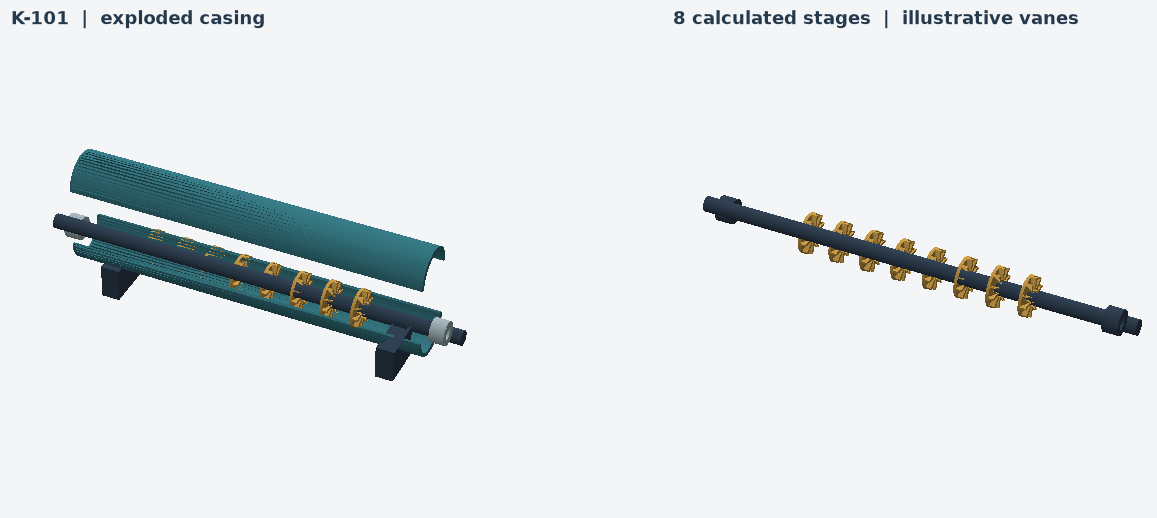

In [11]:
def compressor_scene(spec, exploded=True):
    scene = trimesh.Scene()
    radius = spec["casing_inner_diameter_m"] / 2
    wall = spec["casing_wall_m"]
    length = spec["casing_length_m"]
    center_z = radius + 0.22
    casing_mesh = tube_x(radius, radius + wall, length)
    lower = casing_mesh.slice_plane([0, 0, 0], [0, 0, -1], cap=False)
    upper = casing_mesh.slice_plane([0, 0, 0], [0, 0, 1], cap=False)
    lower.apply_translation([0, 0, center_z])
    upper.apply_translation([0, 0, center_z + (2.6 * radius if exploded else 0.0)])
    add_part(scene, "K-101/lower-casing", lower, colors["shell"])
    add_part(scene, "K-101/upper-casing", upper, colors["shell"])
    shaft = cylinder_x(spec["shaft_diameter_m"] / 2, length * 1.18, [0, 0, center_z])
    add_part(scene, "K-101/shaft", shaft, colors["support"])
    impeller_radius = spec["impeller_diameter_m"] / 2
    pitch = spec["bearing_span_m"] / (spec["stages"] + 1)
    positions = np.linspace(
        -spec["bearing_span_m"] / 2 + pitch, spec["bearing_span_m"] / 2 - pitch, spec["stages"]
    )
    for stage, x in enumerate(positions, start=1):
        disc = tube_x(
            spec["shaft_diameter_m"] / 2, impeller_radius, 0.06 * pitch, [x, 0, center_z]
        )
        pieces = [disc]
        hub_radius = 0.60 * spec["shaft_diameter_m"]
        blade_length = impeller_radius - hub_radius
        for angle in np.linspace(0, 2 * math.pi, 10, endpoint=False):
            blade = box_at(
                [0.22 * pitch, blade_length, 0.012 * impeller_radius],
                [x + 0.10 * pitch, hub_radius + blade_length / 2, 0],
            )
            blade.apply_transform(trimesh.transformations.rotation_matrix(angle, [1, 0, 0]))
            blade.apply_translation([0, 0, center_z])
            pieces.append(blade)
        add_part(
            scene,
            f"K-101/impeller-{stage:02d}-illustrative-vanes",
            trimesh.util.concatenate(pieces),
            colors["rotor"],
        )
    for index, x in enumerate([-0.40 * length, 0.40 * length], start=1):
        add_part(
            scene,
            f"K-101/support-{index}",
            box_at([0.12, radius * 1.8, 0.23], [x, 0, 0.115]),
            colors["support"],
        )
        bearing = tube_x(
            spec["shaft_diameter_m"] / 2,
            spec["shaft_diameter_m"] * 0.85,
            0.10,
            [x * 1.32, 0, center_z],
        )
        add_part(scene, f"K-101/bearing-envelope-{index}", bearing, colors["pipe"])
    return scene


compressor_model = compressor_scene(rotor, exploded=True)
rotor_detail = trimesh.Scene()
for name, mesh in scene_meshes(compressor_model):
    if "impeller" in name or "shaft" in name or "bearing" in name:
        color = colors["rotor"] if "impeller" in name else colors["support"]
        add_part(rotor_detail, name, mesh, color)
static_figure(
    [compressor_model, rotor_detail],
    [
        "K-101  |  exploded casing",
        f"{rotor['stages']} calculated stages  |  illustrative vanes",
    ],
    "compressor_cutaway.png",
)
compressor_view = interactive_scene(
    compressor_model, "K-101 — calculated rotor and casing envelope"
)
compressor_view.show(renderer="plotly_mimetype")

## 8. Change the flow → regenerate the vessel

Each point below runs a fresh NeqSim process and repeats the mechanical calculation. There is no
manual rescaling of a finished STL. The plots therefore show the effect of the model's sizing rules,
including any aspect-ratio rules and rounding. Pressure, composition and temperature are fixed.
The three vessels use the **same spatial scale** in the comparison view.

,Feed [t/h],ID [m],T/T [m],Wall [mm],Gas nozzle ID [m]
0,60.0,1.1161,5.5806,5.2944,0.2
1,100.0,1.4409,7.2046,6.2530,0.3
2,140.0,1.7049,8.5246,7.0322,0.3


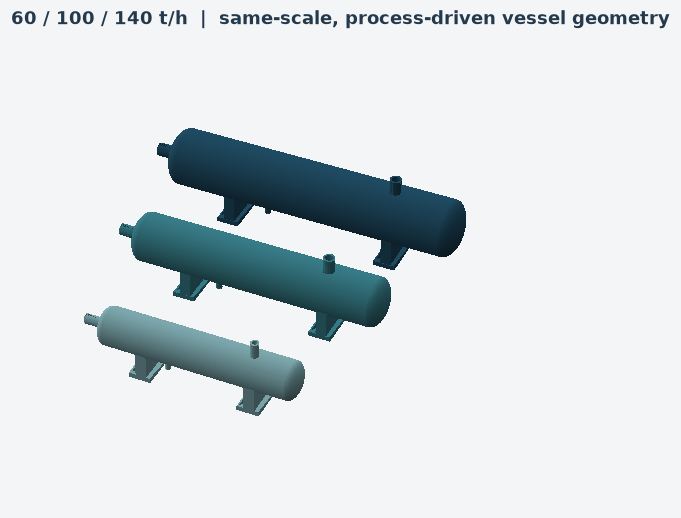

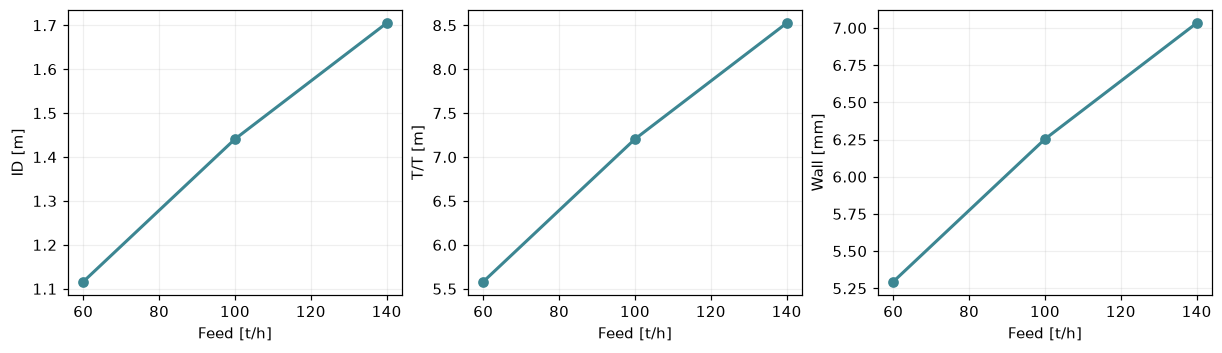

In [12]:
scenario_records = []
scenario_specs = []
for multiplier in [0.60, 1.00, 1.40]:
    case_process, case_feed, case_vessel, case_compressor = build_process(100000.0 * multiplier)
    case_design, case_history = size_vessel(case_vessel)
    case_inlet, case_nozzles = reviewed_nozzles(case_vessel, case_design)
    case_spec = dict(vessel_spec)
    case_spec.update(
        {
            "inner_diameter_m": float(case_design.getInnerDiameter()),
            "tangent_length_m": float(case_design.getTantanLength()),
            "wall_m": float(case_design.getWallThickness()),
            "inlet_id_m": case_inlet,
            "gas_outlet_id_m": float(case_design.getGasOutletNozzleID()),
            "liquid_outlet_id_m": float(case_design.getOilOutletNozzleID()),
            "normal_liquid_level_m": float(case_design.getNLL()),
        }
    )
    scenario_specs.append(case_spec)
    scenario_records.append(
        {
            "Feed [t/h]": multiplier * 100,
            "ID [m]": case_spec["inner_diameter_m"],
            "T/T [m]": case_spec["tangent_length_m"],
            "Wall [mm]": case_spec["wall_m"] * 1000,
            "Gas nozzle ID [m]": case_spec["gas_outlet_id_m"],
        }
    )
scenarios = pd.DataFrame(scenario_records)
display(scenarios.round(4))
assert np.all(np.diff(scenarios["ID [m]"]) > 0)
assert np.all(np.diff(scenarios["T/T [m]"]) > 0)

comparison = trimesh.Scene()
spacing = max(spec["inner_diameter_m"] for spec in scenario_specs) * 2.3
for index, spec in enumerate(scenario_specs):
    for name, mesh in scene_meshes(vessel_scene(spec)):
        mesh.apply_translation([0, spacing * index, 0])
        add_part(
            comparison,
            f"{int(scenarios.iloc[index]['Feed [t/h]'])}t-h/{name}",
            mesh,
            ["#86b5bb", "#3c8692", "#22516a"][index],
        )
static_figure(
    [comparison],
    ["60 / 100 / 140 t/h  |  same-scale, process-driven vessel geometry"],
    "flow_case_models.png",
)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.1), layout="constrained")
for ax, column in zip(axes, ["ID [m]", "T/T [m]", "Wall [mm]"]):
    ax.plot(
        scenarios["Feed [t/h]"], scenarios[column], "o-", color=colors["shell"], linewidth=2
    )
    ax.set(xlabel="Feed [t/h]", ylabel=column)
    ax.grid(alpha=0.2)
fig.savefig(output_dir / "sizing_sensitivity.png", dpi=140, bbox_inches="tight")
plt.show()
plt.close(fig)

## 9. Mesh checks: does the geometry match the specification?

For the closed **external envelope**, the analytic volume is the cylinder plus two half-ellipsoids:

$$V=\pi R^2L+\frac{4\pi R^2h}{3},\qquad h=\frac{R}{2}.$$

$R$ is the external radius in m, $L$ is the tangent length in m and $h$ is one head depth in m;
$V$ is in m³. This volume is an **envelope volume**, not fluid capacity, steel volume or weight.
Nozzle/support overlaps are excluded from this analytic comparison. We check mesh refinement,
watertightness, winding, positive volume, bounding dimensions and STL/GLB round trips.

The compressor cutaway is deliberately open; it must not be labelled a watertight CFD fluid domain.
Likewise an assembly of individually closed solids may contain overlaps. `is_watertight` alone does
not prove a valid manifold assembly, collision-free installation or manufacturing readiness.

In [13]:
external_radius = vessel_spec["inner_diameter_m"] / 2 + vessel_spec["wall_m"]
tangent_length = vessel_spec["tangent_length_m"]
expected_extents = np.array(
    [tangent_length + external_radius, 2 * external_radius, 2 * external_radius]
)
analytic_volume = (
    math.pi * external_radius**2 * tangent_length
    + 4 * math.pi * external_radius**2 * (external_radius / 2) / 3
)
mesh_records = []
for sections in [32, 64, 128]:
    envelope = vessel_envelope(
        external_radius, tangent_length, sections=sections, head_steps=sections // 3
    )
    relative_error = abs(envelope.volume / analytic_volume - 1.0)
    assert envelope.is_watertight and envelope.is_winding_consistent
    assert envelope.volume > 0 and np.isfinite(envelope.vertices).all()
    assert np.allclose(envelope.extents, expected_extents, rtol=1e-10)
    mesh_records.append(
        {
            "Circumferential sections": sections,
            "Triangles": len(envelope.faces),
            "Envelope volume [m³]": envelope.volume,
            "Relative volume error [%]": relative_error * 100,
        }
    )
mesh_validation = pd.DataFrame(mesh_records)
display(mesh_validation.round(6))
assert np.all(np.diff(mesh_validation["Relative volume error [%]"]) < 0)
assert relative_error < 0.001
print(f"Analytic external-envelope volume: {analytic_volume:.6f} m³")

Analytic external-envelope volume: 12.756967 m³


,Circumferential sections,Triangles,Envelope volume [m³],Relative volume error [%]
0,32,1152,12.669088,0.688870
1,64,5120,12.735247,0.170257
2,128,20992,12.751549,0.042466


## 10. Export and inspect an STL — including your own file

**STL** stores triangles; it does not reliably carry units, equipment tags, colors or design
provenance. **GLB** preserves a scene with named, colored components and is a better visual handoff.
The JSON sidecar preserves the engineering meaning. Neither format is an exact parametric CAD model.

The default STL import below reads the generated vessel envelope, so the notebook remains executable
without uploads. To inspect a colleague's model, upload the STL with Colab's Files panel, set
`STL_PATH` and explicitly set `STL_UNIT` to `m`, `mm` or `cm`, then rerun the import cell. A screenshot
cannot supply triangle connectivity, dimensions, units or solid topology. Do not guess its scale.

In [14]:
envelope_path = output_dir / "V-101_external_envelope_m.stl"
envelope.export(envelope_path)
separator_model.export(output_dir / "V-101_visual_assembly.glb")
compressor_model.export(output_dir / "K-101_exploded_cutaway.glb")
(output_dir / "design_handoff.json").write_text(json.dumps(handoff, indent=2), encoding="utf-8")
scenarios.to_csv(output_dir / "flow_case_dimensions.csv", index=False)
mesh_validation.to_csv(output_dir / "mesh_validation.csv", index=False)
separator_view.write_html(output_dir / "V-101_interactive.html", include_plotlyjs=True)
compressor_view.write_html(output_dir / "K-101_interactive.html", include_plotlyjs=True)

loaded_envelope = trimesh.load_mesh(envelope_path, process=True)
assert loaded_envelope.is_watertight
assert np.allclose(loaded_envelope.extents, envelope.extents, rtol=2e-6)
assert math.isclose(loaded_envelope.volume, envelope.volume, rel_tol=2e-6)
loaded_scene = trimesh.load_scene(output_dir / "V-101_visual_assembly.glb")
assert np.allclose(loaded_scene.bounds, separator_model.bounds, rtol=2e-6, atol=1e-7)
assert len(loaded_scene.geometry) == len(separator_model.geometry)
print("STL: bounds and volume preserved. GLB: bounds and part count preserved.")

STL: bounds and volume preserved. GLB: bounds and part count preserved.


,File,Triangles,x extent [m],y extent [m],z extent [m],Watertight,Consistent winding
0,V-101_external_envelope_m.stl,20992,7.931298,1.453423,1.453423,True,True


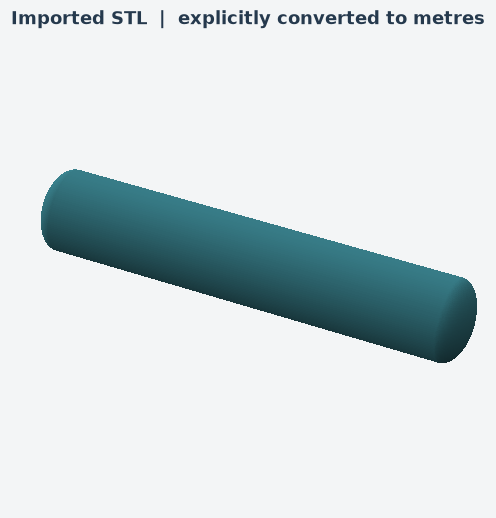

In [15]:
STL_PATH = envelope_path  # Replace with an uploaded file path to inspect another model.
STL_UNIT = "m"  # Must be supplied from the file's design/export basis.
unit_scale = {"m": 1.0, "mm": 0.001, "cm": 0.01}
if STL_UNIT not in unit_scale:
    raise ValueError("Unknown STL units; resolve them before importing.")
imported_mesh = trimesh.load_mesh(Path(STL_PATH), process=True)
if not isinstance(imported_mesh, trimesh.Trimesh) or len(imported_mesh.faces) == 0:
    raise ValueError("Expected a nonempty triangular mesh.")
if not np.isfinite(imported_mesh.vertices).all():
    raise ValueError("STL contains non-finite coordinates.")
imported_mesh.apply_scale(unit_scale[STL_UNIT])
imported_mesh.units = "m"
display(
    pd.DataFrame(
        [
            {
                "File": Path(STL_PATH).name,
                "Triangles": len(imported_mesh.faces),
                "x extent [m]": imported_mesh.extents[0],
                "y extent [m]": imported_mesh.extents[1],
                "z extent [m]": imported_mesh.extents[2],
                "Watertight": imported_mesh.is_watertight,
                "Consistent winding": imported_mesh.is_winding_consistent,
            }
        ]
    )
)
imported_scene = trimesh.Scene()
add_part(imported_scene, "imported-STL", imported_mesh, colors["shell"])
static_figure(
    [imported_scene], ["Imported STL  |  explicitly converted to metres"], "imported_stl.png"
)
imported_view = interactive_scene(
    imported_scene, "Inspect the imported STL — coordinates in metres"
)
imported_view.show(renderer="plotly_mimetype")

## 11. Package the result and preserve traceability

The package contains models, self-contained interactive HTML viewers, saved figures, dimensions,
checks and the JSON design basis. The HTML files can be opened locally after downloading the ZIP.
Re-running from changed inputs produces new geometry; retain separate revision folders in a real
project so an approved design is not overwritten.

In [16]:
validation_summary = {
    "separator_mass_relative_error": mass_error,
    "rotor_tip_speed_relative_error": abs(tip_from_geometry / rotor["tip_speed_m_s"] - 1),
    "finest_envelope_volume_relative_error": relative_error,
    "checks_passed": [
        "separator and compressor mass conservation",
        "positive finite design dimensions",
        "repeated vessel sizing convergence",
        "reviewed outlet nozzle velocity limits",
        "rotor diameter/speed/tip-speed identity",
        "three flow cases recalculated",
        "watertight envelope and consistent winding",
        "analytic volume and mesh refinement",
        "expected external dimensions",
        "STL bounds/volume round trip",
        "GLB bounds/part count",
    ],
    "source_issues": [3675, 3676, 3677, 3678],
    "excluded": [
        "design certification",
        "manufacturing tolerance",
        "CFD mesh qualification",
        "rotordynamic validation",
        "assembly boolean/penetration checks",
    ],
}
(output_dir / "validation_summary.json").write_text(
    json.dumps(validation_summary, indent=2),
    encoding="utf-8",
)
files = sorted(
    path
    for path in output_dir.iterdir()
    if path.is_file() and path.name != "sha256_manifest.json"
)
manifest = {path.name: hashlib.sha256(path.read_bytes()).hexdigest() for path in files}
(output_dir / "sha256_manifest.json").write_text(
    json.dumps(manifest, indent=2), encoding="utf-8"
)
archive_path = shutil.make_archive("mechanical_design_3d_package", "zip", output_dir)
display(
    pd.DataFrame(
        [
            {"Artifact": path.name, "Size [kB]": path.stat().st_size / 1000}
            for path in sorted(output_dir.iterdir())
        ]
    ).round(1)
)
try:
    from google.colab import files as colab_files
except ImportError:
    display(FileLink(Path(archive_path).name))
else:
    colab_files.download(archive_path)
print(json.dumps(validation_summary, indent=2))

{
  "separator_mass_relative_error": 2.3101165425032383e-13,
  "rotor_tip_speed_relative_error": 2.220446049250313e-16,
  "finest_envelope_volume_relative_error": 0.00042465589883411425,
  "checks_passed": [
    "separator and compressor mass conservation",
    "positive finite design dimensions",
    "repeated vessel sizing convergence",
    "reviewed outlet nozzle velocity limits",
    "rotor diameter/speed/tip-speed identity",
    "three flow cases recalculated",
    "watertight envelope and consistent winding",
    "analytic volume and mesh refinement",
    "expected external dimensions",
    "STL bounds/volume round trip",
    "GLB bounds/part count"
  ],
  "source_issues": [
    3675,
    3676,
    3677,
    3678
  ],
  "excluded": [
    "design certification",
    "manufacturing tolerance",
    "CFD mesh qualification",
    "rotordynamic validation",
    "assembly boolean/penetration checks"
  ]
}


,Artifact,Size [kB]
0,K-101_exploded_cutaway.glb,64.1
1,K-101_interactive.html,4467.4
2,V-101_external_envelope_m.stl,1049.7
3,V-101_interactive.html,4456.1
4,V-101_visual_assembly.glb,109.1
5,compressor_cutaway.png,52.1
6,design_handoff.json,2.3
7,flow_case_dimensions.csv,0.3
8,flow_case_models.png,37.3
9,imported_stl.png,23.1


/workspace/scratch/314126d77740/repo/notebooks/process/mechanical_design_3d_package.zip

## 12. Where this workflow can help

**Early project development.** A process engineer can compare flows, pressures or compositions and
immediately see how preliminary vessel size and space requirements change. Equipment tags and
dimensions can be shared with layout engineers before detailed supplier models exist. Add actual
maintenance, lifting and escape-route requirements before interpreting a layout as feasible.

**Design reviews and teaching.** An interactive cutaway communicates equipment scale and internal
arrangement more clearly than a list of numbers. Color should distinguish components or declared
data provenance; it must not suggest a computed stress field unless such a calculation exists.

**Agent-assisted engineering.** An agent can orchestrate model runs, extract a schema, regenerate
meshes, compare revisions and report failed checks. It should be required to show the calculation
case and validation evidence for every changed dimension. A rendered image is an explanation of
the design data, not evidence that the engineering is correct.

**Digital twins and existing facilities.** Import a reviewed vendor STL/STEP model, retain its
identity and units, and connect it to NeqSim equipment tags. Simulation results can then be shown as
overlays. Do not automatically deform an installed-equipment model when operating conditions change:
rate the existing geometry first, and keep a proposed redesign as a separate revision.

### Choosing an open-source geometry tool

| Tool | Useful role | Boundary |
|---|---|---|
| Trimesh | Fast parametric triangle meshes, STL/GLB import/export, bounds and mesh QA | No manufacturing feature history; inspect boolean/topology requirements |
| Plotly | Interactive notebook meshes and result overlays | Viewer, not a CAD or engineering solver |
| CadQuery / OpenCascade | Exact solids, parametric features, STEP exchange | More geometric modelling and CAD validity checks required |
| FreeCAD | Interactive engineering CAD, assemblies and drawings | Requires CAD workflow and reviewed dimensions |
| Gmsh + OpenFOAM | Mesh and solve a defined fluid domain | Needs a distinct watertight fluid volume, boundaries and numerical validation |

For fabrication-oriented work, pass this contract to CadQuery, generate real shell/nozzle booleans,
apply appropriate head and flange details, and export STEP. For CFD, build the internal fluid volume
separately. Meshing the external visualization would not solve the intended internal-flow problem.

### Fit into the example book

1. Start with [Separators](Separators.ipynb) and [compressor calculations](GasCompressors.ipynb) for
   process behaviour and operating limits.
2. Use **this notebook** for the calculated-mechanical-data → qualified 3D geometry handoff.
3. Continue to [parametric CAD–Gmsh–OpenFOAM](../fluidflow/neqsim_cadquery_gmsh_openfoam_workflow.ipynb)
   for exact CAD and CFD, or [P&ID/datasheet to CAD/CFD](../fluidflow/pid_datasheet_to_cad_cfd_neqsim.ipynb)
   for reviewed design-document inputs.
4. Connect dimensional trade-offs to [process cost estimation and economics](../fielddevelopment/process_cost_estimation_and_economics.ipynb).

### Exercises

- Replace the rich feed with a gas-scrubber service and use the appropriate NeqSim equipment design.
  Confirm that the expected liquid phase and nozzle requirements exist; do not silently reuse a
  liquid-rich separator case for a dry gas vessel.
- Change flow to 80 or 120 t/h. Explain the changes in diameter, length, wall and nozzle ID using
  the printed calculations, not visual scale alone.
- Add reviewed nozzle coordinates and orientations to the JSON contract. Check local versus plant
  coordinates and the equipment tag on import/export.
- Import an STL in millimetres and verify one known dimension after conversion. Explain why a
  watertight mesh can still be unsuitable as a fluid domain or manufacturing assembly.
- Replace the illustrative compressor vanes with a licensed vendor model, while keeping calculated
  performance and vendor geometry as separate sources of evidence.

## Validation and limitations

Stored outputs come from a clean sequential execution. The notebook checks physical conservation,
dimensional consistency, repeated sizing, outlet velocities, flow-case response, mesh refinement,
analytic envelope volume and file round trips. These are independent geometry/consistency checks,
not validation of all NeqSim mechanical correlations. Static fallbacks are retained for all
interactive models; rendered Markdown, equations, tables and figures are visually reviewed before
publication.

The discovered source limitations are tracked in [#3675](https://github.com/equinor/neqsim/issues/3675),
[#3676](https://github.com/equinor/neqsim/issues/3676),
[#3677](https://github.com/equinor/neqsim/issues/3677) and
[#3678](https://github.com/equinor/neqsim/issues/3678). The explicit checks and corrections above
are local to this teaching workflow; they do not repair the NeqSim library. Requalify them when
those implementations change. Geometry generation stops when a required check fails.

## Sources

- [NeqSim mechanical-design guide](https://github.com/equinor/neqsim/blob/master/docs/process/mechanical_design.md)
  and the exact source commit printed above. Units were verified against implementation, including
  `PressureVesselDesignStandard.calcWallThickness` and compressor mechanical getters.
- [Trimesh documentation](https://trimesh.org/) and [creation API](https://trimesh.org/trimesh.creation.html):
  surface-of-revolution meshes, primitives, scenes and mesh inspection.
- [Plotly Mesh3d](https://plotly.com/python/3d-mesh/): explicit vertices and triangle connectivity.
- [CadQuery introduction](https://cadquery.readthedocs.io/en/latest/intro.html): parametric CAD and
  STEP-oriented follow-on work.
- [FreeCAD](https://www.freecad.org/): open-source parametric CAD.

No colleague/vendor STL is distributed with this example; the models are generated from the
synthetic inputs and explicitly stated geometric assumptions in this notebook.